In [1]:
from fixture.factory.feature.closes import factory_closes_n4

closes_n4 = factory_closes_n4()
closes_n4

Date,now,lag_1,lag_2,lag_3,lag_4
datetime[μs],f64,f64,f64,f64,f64
2000-01-06 00:00:00,71.66349,-41.86609,12.939832,177.867323,-227.544524
2000-01-07 00:00:00,55.385366,71.66349,-41.86609,12.939832,177.867323
2000-01-08 00:00:00,-44.481861,55.385366,71.66349,-41.86609,12.939832
2000-01-09 00:00:00,52.369074,-44.481861,55.385366,71.66349,-41.86609
2000-01-10 00:00:00,49.154641,52.369074,-44.481861,55.385366,71.66349
…,…,…,…,…,…
2000-04-05 00:00:00,45.418811,139.391377,-75.082474,47.799894,121.93544
2000-04-06 00:00:00,-11.103915,45.418811,139.391377,-75.082474,47.799894
2000-04-07 00:00:00,25.889982,-11.103915,45.418811,139.391377,-75.082474


In [2]:
import lightgbm as lgb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 特徴量とターゲットの分割（to_pandas()で変換）
X = closes_n4[['lag_1', 'lag_2', 'lag_3', 'lag_4']].to_pandas()
y = closes_n4['now'].to_numpy()  # numpy配列に変換

# 時系列を考慮したデータ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# LightGBM用データセット作成（labelをnumpy配列で指定）
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 回帰用パラメータ設定
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# モデル訓練
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(20)]
)

# 予測と評価
y_pred = np.asarray(model.predict(X_test))  # numpy配列に明示的に変換
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE: {rmse:.4f}')

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[53]	valid_0's rmse: 76.0379
Test RMSE: 76.0379


MAE: 64.26
R2 Score: -0.03


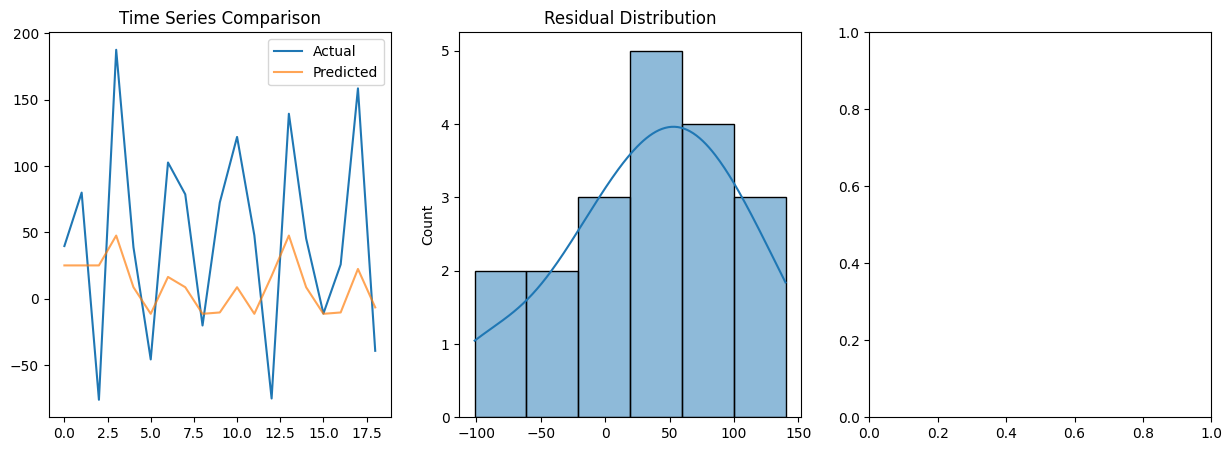

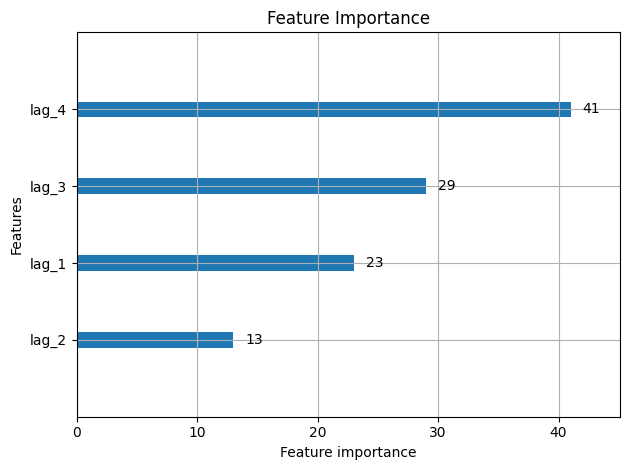

In [ ]:
# 追加の評価指標
from sklearn.metrics import mean_absolute_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. 実際値 vs 予測値の時系列プロット
plt.subplot(1, 3, 1)
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Time Series Comparison')
plt.legend()

# 2. 残差プロット
plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, kde=True)
plt.title('Residual Distribution')

# 3. 特徴量重要度
plt.subplot(1, 3, 3)
lgb.plot_importance(model, max_num_features=10)
plt.title('Feature Importance')

plt.tight_layout()
plt.show()